# 01 · Python en VS Code, lo justo para la clase

**Objetivo (50 min):** que al terminar puedas leer y modificar el notebook del proceso gaussiano
sin que la sintaxis te estorbe. No es un curso de Python; es el mínimo que vamos a usar hoy.

Cómo trabajar en VS Code:

| Acción | Cómo |
|---|---|
| Ejecutar una celda | `Shift + Enter` (ejecuta y pasa a la siguiente) |
| Añadir celda de código abajo | botón `+ Code` o tecla `B` estando fuera de la celda |
| Ver qué contiene una variable | escríbela sola al final de la celda |
| Ayuda de una función | escribe `np.linspace?` o pasa el mouse encima |
| Reiniciar si todo se enredó | botón *Restart* arriba del notebook |

Durante la clase verás bloques marcados **🟡 Tu turno**. Son cortos (2–3 min) y se hacen en el momento.

## 1. Variables, números y texto

In [1]:
capacidad = 150        # MW  (un entero)
demanda   = 132.7      # MW  (un decimal)
ciudad    = "Tepoztlán"  # texto

reserva = capacidad - demanda
print("Ciudad:", ciudad)
print("Reserva:", reserva, "MW")
print(f"La reserva es {reserva/capacidad:.1%} de la capacidad")   # f-string: texto con variables dentro

Ciudad: Tepoztlán
Reserva: 17.30000000000001 MW
La reserva es 11.5% de la capacidad


🟡 **Tu turno.** Cambia la demanda a 160 y vuelve a ejecutar. ¿Qué signo tiene la reserva? ¿Qué significa físicamente?

## 2. Listas y arreglos de NumPy

Una **lista** guarda cosas en orden. Un **arreglo de NumPy** es una lista de números con superpoderes:
opera sobre todos los elementos a la vez, que es justo lo que necesitamos para series de tiempo.

In [2]:
import numpy as np

demanda_lista = [118, 121, 125, 130, 128, 122, 119]       # lunes a domingo, MW
demanda = np.array(demanda_lista)

print("promedio  :", demanda.mean())
print("máximo    :", demanda.max())
print("en GW     :", demanda / 1000)          # se divide TODO el arreglo
print("primer día:", demanda[0])              # Python cuenta desde 0
print("último día:", demanda[-1])
print("fin de semana:", demanda[5:7])         # del índice 5 al 6 (el 7 no entra)

promedio  : 123.28571428571429
máximo    : 130
en GW     : [0.118 0.121 0.125 0.13  0.128 0.122 0.119]
primer día: 118
último día: 119
fin de semana: [122 119]


In [3]:
# Máscaras booleanas: elegir elementos con una condición
dias = np.arange(7)                 # 0,1,2,...,6
alta = demanda > 124
print(alta)
print("días con demanda alta:", dias[alta])
print("esos valores        :", demanda[alta])

[False False  True  True  True False False]
días con demanda alta: [2 3 4]
esos valores        : [125 130 128]


🟡 **Tu turno.** Obtén los días en que la demanda estuvo **por debajo del promedio**.

In [4]:
# escribe aquí



## 3. Funciones útiles de NumPy que usaremos hoy

In [5]:
x = np.linspace(0, 10, 5)      # 5 puntos igualmente espaciados entre 0 y 10
print("linspace :", x)
print("exp      :", np.exp(-x))
print("ceros    :", np.zeros(3))
print("identidad:\n", np.eye(3))

rng = np.random.default_rng(semilla := 0)     # generador de números aleatorios reproducible
print("ruido    :", rng.normal(0, 1, 3))      # 3 números normales, media 0, desviación 1

linspace : [ 0.   2.5  5.   7.5 10. ]
exp      : [1.00000000e+00 8.20849986e-02 6.73794700e-03 5.53084370e-04
 4.53999298e-05]
ceros    : [0. 0. 0.]
identidad:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
ruido    : [ 0.12573022 -0.13210486  0.64042265]


### Matrices y el producto `@`

En la segunda parte vamos a multiplicar matrices. En NumPy `*` multiplica **elemento por elemento**
y `@` hace el **producto matricial** (el de álgebra lineal). No los confundas.

In [6]:
A = np.array([[1, 2],
              [3, 4]])
v = np.array([10, 20])
print("A * 2  =\n", A * 2)
print("A @ v  =", A @ v)          # [1*10+2*20, 3*10+4*20]
print("A.T    =\n", A.T)          # transpuesta
print("diag   =", np.diag(A))     # diagonal

A * 2  =
 [[2 4]
 [6 8]]
A @ v  = [ 50 110]
A.T    =
 [[1 3]
 [2 4]]
diag   = [1 4]


### Broadcasting: restar cada elemento contra cada elemento

Esta idea la usaremos para calcular distancias entre **todos** los pares de días de una sola vez.
`a[:, None]` convierte un vector fila en columna; al restarle un vector fila, NumPy expande ambos y produce una tabla.

In [7]:
a = np.array([0., 1., 2.])
b = np.array([0., 5.])
print(a[:, None] - b[None, :])     # tabla 3x2: fila i, columna j = a[i] - b[j]

[[ 0. -5.]
 [ 1. -4.]
 [ 2. -3.]]


## 4. Funciones: empaquetar una receta

In [8]:
def reserva_pct(capacidad, demanda):
    """Porcentaje de capacidad que queda libre."""
    return (capacidad - demanda) / capacidad * 100

print(reserva_pct(150, 132.7))
print(reserva_pct(150, np.array([118, 121, 160])))   # también funciona con arreglos

11.533333333333342
[21.33333333 19.33333333 -6.66666667]


🟡 **Tu turno.** Escribe una función `kilowatts(mw)` que convierta MW a kW y pruébala con `demanda`.

In [9]:
# escribe aquí



## 5. Gráficas con matplotlib

Una gráfica = ejes + datos + etiquetas. Con estas cinco líneas resuelves el 90 % de lo que necesitas.

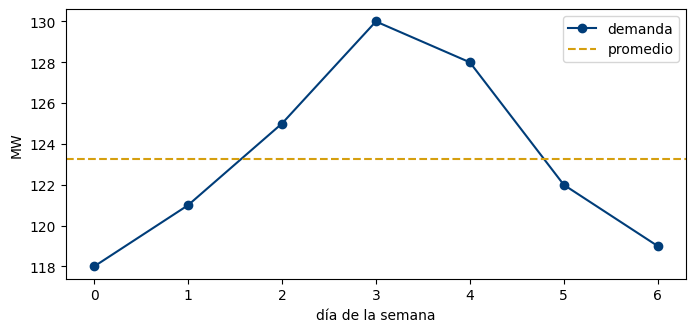

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
plt.plot(dias, demanda, "o-", color="#003D79", label="demanda")
plt.axhline(demanda.mean(), color="#D59F0F", linestyle="--", label="promedio")
plt.xlabel("día de la semana"); plt.ylabel("MW"); plt.legend()
plt.show()

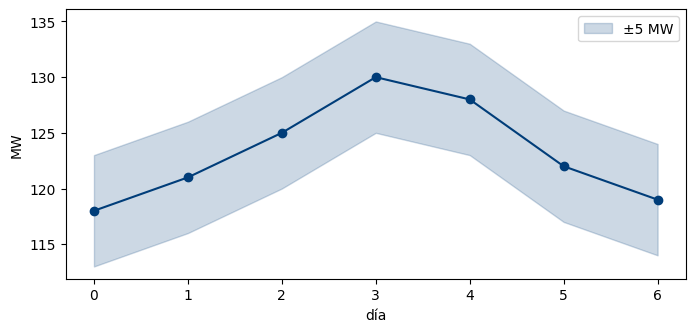

In [11]:
# Bandas sombreadas: así dibujaremos la incertidumbre en la segunda parte
inferior = demanda - 5
superior = demanda + 5
plt.figure(figsize=(8, 3.5))
plt.fill_between(dias, inferior, superior, color="#003D79", alpha=0.2, label="±5 MW")
plt.plot(dias, demanda, "o-", color="#003D79")
plt.legend(); plt.xlabel("día"); plt.ylabel("MW")
plt.show()

## 6. Tablas con pandas (leer y guardar datos)

Los datos reales llegan en Excel o CSV. `pandas` los abre como una tabla (`DataFrame`).

In [12]:
import pandas as pd

tabla = pd.DataFrame({"dia": ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"],
                      "demanda_MW": demanda})
tabla.to_csv("demanda_semana.csv", index=False)    # guardar
tabla2 = pd.read_csv("demanda_semana.csv")         # leer
tabla2

,dia,demanda_MW
0,lun,118
1,mar,121
2,mié,125
3,jue,130
4,vie,128
5,sáb,122
6,dom,119


In [13]:
print(tabla2["demanda_MW"].describe())          # resumen estadístico
print("como arreglo de NumPy:", tabla2["demanda_MW"].to_numpy())

count      7.000000
mean     123.285714
std        4.535574
min      118.000000
25%      120.000000
50%      122.000000
75%      126.500000
max      130.000000
Name: demanda_MW, dtype: float64
como arreglo de NumPy: [118 121 125 130 128 122 119]


## 7. Un ciclo `for` y un `if`, por si hacen falta

In [14]:
for d, mw in zip(tabla2["dia"], tabla2["demanda_MW"]):
    if mw > demanda.mean():
        print(f"{d}: {mw} MW  ← arriba del promedio")
    else:
        print(f"{d}: {mw} MW")

lun: 118 MW
mar: 121 MW
mié: 125 MW  ← arriba del promedio
jue: 130 MW  ← arriba del promedio
vie: 128 MW  ← arriba del promedio
sáb: 122 MW
dom: 119 MW


## 8. Errores que verás (y qué hacer)

| Error | Causa típica | Arreglo |
|---|---|---|
| `NameError: name 'np' is not defined` | No ejecutaste la celda del `import` | Ejecuta las celdas en orden desde arriba |
| `IndexError: index 7 is out of bounds` | Pediste un elemento que no existe (recuerda: empieza en 0) | Revisa el índice |
| `ValueError: operands could not be broadcast` | Sumaste arreglos de tamaños distintos | Imprime `.shape` de cada uno |
| `SyntaxError` con una flecha `^` | Falta un paréntesis o dos puntos | Mira justo donde apunta la flecha |
| `ModuleNotFoundError` | La librería no está en este entorno | `pip install ...` en la terminal y confirma que dice `.venv` |

🟡 **Tu turno (cierre).** Provoca a propósito un `IndexError` con `demanda[7]`, lee el mensaje y arréglalo. Leer errores es la habilidad número uno.

In [15]:
# escribe aquí



---
**Listo.** Con esto puedes leer el notebook `02_proceso_gaussiano_desde_cero.ipynb`: arreglos, `@`, broadcasting, funciones y `fill_between` es todo lo que usa.